In [16]:
import pandas as pd

file_path = r"E:\Grad\data\东南大学齿轮箱数据\bearingset\ball_20_0.csv"  # 换成你的实际文件名
# 跳过前 16 行说明，只读数值
df = pd.read_csv(file_path, header=None, skiprows=16)
df

,0,1,2,3,4,5,6,7,8
0,-0.131940,-0.003675,-0.007886,-0.006003,-0.009137,0.004551,0.000236,0.000334,NaN
1,-0.134883,-0.000161,0.003791,0.004156,-0.002578,0.006244,-0.002215,-0.007107,NaN
2,-0.136186,-0.000046,-0.002126,-0.000608,0.002059,0.000831,0.000814,0.000023,NaN
3,-0.134126,-0.000200,-0.001577,-0.003772,-0.001578,-0.001233,-0.000161,0.004441,NaN
4,-0.136193,0.001631,0.002419,0.004975,-0.006818,-0.007070,-0.002962,0.001920,NaN
...,...,...,...,...,...,...,...,...,...
1048555,-0.136644,-0.001228,-0.005304,0.002154,0.005057,0.007437,0.003976,-0.004729,NaN
1048556,-0.135646,0.001791,0.002497,0.001574,0.000437,-0.001198,0.006135,-0.012242,NaN
1048557,-0.137790,0.002385,-0.001674,0.001507,0.001581,-0.003831,-0.001885,-0.001711,NaN
1048558,-0.140858,0.005471,0.008260,0.001360,0.008322,-0.004454,0.001184,0.005413,NaN


In [17]:
import os
import glob
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# =================🎛️ 配置区域=================
DATA_ROOT = r"E:\Grad\data\东南大学齿轮箱数据"
BEARING_DIR = os.path.join(DATA_ROOT, "bearingset")
GEAR_DIR = os.path.join(DATA_ROOT, "gearset")

MAX_FILES_TO_PROCESS = None

CHINESE_COL_NAMES = [
    "电机振动",
    "行星齿轮箱振动_x",
    "行星齿轮箱振动_y",
    "行星齿轮箱振动_z",
    "电机转矩",
    "平行齿轮箱振动_x",
    "平行齿轮箱振动_y",
    "平行齿轮箱振动_z",
]

# 🎯 预处理配置
NORMALIZATION_METHOD = "min-max"  # 选项: "z-score" (标准差标准化) 或 "min-max" (归一化)
SAVE_STATS = True  # 是否保存均值/方差以便后续测试集使用
# =========================================


def parse_file_universal_v2(file_path, folder_type):
    """通用解析器 V2 (保持不变)"""
    df = None
    skip_rows = 17 if folder_type == 'gear' else 16
    strategy_used = ""

    try:
        df = pd.read_csv(file_path,
                         sep=r'\s+',
                         skiprows=skip_rows,
                         header=None,
                         engine='python',
                         on_bad_lines='skip')
        if df.shape[1] >= 8:
            strategy_used = "空格分隔模式"
        else:
            raise ValueError(f"列数不足 ({df.shape[1]})")
    except Exception:
        try:
            df = pd.read_csv(file_path, header=None, skiprows=16)
            strategy_used = "降级兼容模式 (ball_20_0 专用)"
        except Exception as e:
            return None, f"两种读取方式均失败：{str(e)}"

    if df is None or df.empty:
        return None, "DataFrame 为空"

    df_numeric = df.apply(pd.to_numeric, errors='coerce')
    valid_counts = df_numeric.notna().sum()
    sorted_cols = valid_counts.sort_values(ascending=False).index.tolist()
    top_8_cols = sorted_cols[:8]

    if len(top_8_cols) < 8:
        return None, f"有效数值列不足 8 列"

    data_part = df_numeric[top_8_cols].dropna()
    if len(data_part) < 50:
        return None, f"有效数据行数太少"

    return data_part.values.astype(np.float32), strategy_used


def apply_normalization(df, method="z-score"):
    """
    【核心功能】对 DataFrame 进行按通道标准化/归一化
    逻辑：识别列名中的传感器前缀，对同一传感器的所有故障列分别计算统计量并转换
    """
    print(f"\n⚖️ 正在执行 [{method.upper()}] 标准化处理...")

    # 用于存储统计量 (方便后续测试集使用相同的参数)
    stats_dict = {}

    # 深拷贝以避免 SettingWithCopyWarning
    df_norm = df.copy().astype(np.float32)

    total_cols = len(df_norm.columns)
    processed_count = 0

    # 遍历每一个传感器类型 (例如："电机振动")
    for sensor in CHINESE_COL_NAMES:
        # 找到所有属于该传感器的列 (例如：电机振动_gear_..., 电机振动_bearing_...)
        target_cols = [
            col for col in df_norm.columns if col.startswith(sensor)
        ]

        if not target_cols:
            continue

        # --- 方案 A: 全局统计 (所有文件的该传感器一起算均值方差) ---
        # 优点：不同工况下的分布被统一拉平
        # 缺点：如果某个故障幅值极大，可能会压缩正常数据的分布
        all_vals = df_norm[target_cols].values.flatten()

        if method == "z-score":
            mean_val = np.mean(all_vals)
            std_val = np.std(all_vals)
            if std_val < 1e-9: std_val = 1.0  # 防止除零

            df_norm[target_cols] = (df_norm[target_cols] - mean_val) / std_val

            if SAVE_STATS:
                for col in target_cols:
                    stats_dict[col] = {
                        "mean": float(mean_val),
                        "std": float(std_val)
                    }

        elif method == "min-max":
            min_val = np.min(all_vals)
            max_val = np.max(all_vals)
            range_val = max_val - min_val
            if range_val < 1e-9: range_val = 1.0

            df_norm[target_cols] = (df_norm[target_cols] - min_val) / range_val

            if SAVE_STATS:
                for col in target_cols:
                    stats_dict[col] = {
                        "min": float(min_val),
                        "max": float(max_val)
                    }

        processed_count += len(target_cols)
        # 打印进度 (每处理一个传感器打印一次)
        # print(f"   ✅ 完成传感器 '{sensor}' ({len(target_cols)} 列)")

    print(f"   🎉 标准化完成！共处理 {processed_count}/{total_cols} 列。")

    # 简单验证：检查是否有 NaN 或 Inf
    if df_norm.isnull().any().any():
        print("   ⚠️ 警告：标准化后检测到 NaN 值！")
    if np.isinf(df_norm.values).any():
        print("   ⚠️ 警告：标准化后检测到 Inf 值！")

    return df_norm, stats_dict


def read_combined_data_horizontal_merge():
    dfs_dict = {}
    failed_files = []
    folders_config = [(BEARING_DIR, 'bearing'), (GEAR_DIR, 'gear')]
    all_files_info = []
    extensions = ["*.csv", "*.txt", "*.xlsx", "*.xls"]

    print("🔍 正在扫描并混合解析文件...")
    for folder, f_type in folders_config:
        if not os.path.exists(folder):
            continue
        files = []
        for ext in extensions:
            files.extend(glob.glob(os.path.join(folder, ext)))
        for f in files:
            all_files_info.append((f, f_type))

    all_files_info.sort(key=lambda x: os.path.basename(x[0]))
    total_found = len(all_files_info)
    limit = min(MAX_FILES_TO_PROCESS,
                total_found) if MAX_FILES_TO_PROCESS else total_found
    print(f"✅ 共发现 {total_found} 个文件，计划处理 {limit} 个。\n")

    success_count = 0
    for i, (file_path, f_type) in enumerate(all_files_info):
        if i >= limit: break
        filename = os.path.basename(file_path)
        raw_name = os.path.splitext(filename)[0]
        fault_id = f"{f_type}_{raw_name}".lower()
        type_tag = "[Gear]" if f_type == 'gear' else "[Bear]"
        print(f"⏳ [{i+1}/{limit}] {type_tag} 解析：{filename}", end='\r')

        data_array, strategy = parse_file_universal_v2(file_path, f_type)

        if data_array is not None:
            df_temp = pd.DataFrame(data_array, columns=CHINESE_COL_NAMES)
            new_cols = [f"{col}_{fault_id}" for col in CHINESE_COL_NAMES]
            df_temp.columns = new_cols

            if fault_id in dfs_dict:
                continue  # 跳过重复
            dfs_dict[fault_id] = df_temp
            success_count += 1
        else:
            failed_files.append((filename, strategy))

    print("\n" + "=" * 60)
    print(f"✅ 成功解析：{success_count} 个文件")
    if failed_files:
        print(f"❌ 失败文件：{len(failed_files)} 个 (详见日志)")

    if not dfs_dict:
        return None, None

    # ================= 1. 合并逻辑 =================
    print(f"\n🚀 正在执行横向合并...")
    lengths = [len(df) for df in dfs_dict.values()]
    min_len = min(lengths)
    max_len = max(lengths)

    if min_len != max_len:
        print(f"⚠️ 长度不一致 (Min:{min_len}, Max:{max_len}) -> 截取至最短")

    final_dfs = []
    for fid, df in dfs_dict.items():
        final_dfs.append(df.reset_index(drop=True).iloc[:min_len])

    final_df = pd.concat(final_dfs, axis=1)
    print(f"   📦 合并后形状：{final_df.shape}")

    # ================= 2. 标准化/归一化逻辑 (新增) =================
    final_df_norm, stats = apply_normalization(final_df,
                                               method=NORMALIZATION_METHOD)

    # 如果需要，可以将 stats 保存为 pickle 文件，供测试集使用
    if SAVE_STATS:
        import pickle
        stats_path = os.path.join(DATA_ROOT, "normalization_stats.pkl")
        with open(stats_path, 'wb') as f:
            pickle.dump(stats, f)
        print(f"   💾 统计参数已保存至：{stats_path}")

    # ================= 3. 验证与返回 =================
    print(f"\n📊 最终结果预览:")
    print(f"   - 形状：{final_df_norm.shape}")
    print(f"   - 数据类型：{final_df_norm.dtypes.iloc[0]}")

    # 随机抽取一列检查统计特性
    sample_col = final_df_norm.columns[0]
    sample_mean = final_df_norm[sample_col].mean()
    sample_std = final_df_norm[sample_col].std()
    print(
        f"   - 抽样检查 ('{sample_col}'): Mean={sample_mean:.4f}, Std={sample_std:.4f}"
    )

    if NORMALIZATION_METHOD == "z-score":
        if abs(sample_mean) < 0.001 and abs(sample_std - 1.0) < 0.001:
            print("   ✅ 标准化验证通过 (Mean≈0, Std≈1)")
        else:
            print("   ⚠️ 标准化结果略有偏差，属正常现象（由于浮点精度或截断）")

    return final_df_norm, stats


if __name__ == "__main__":
    # 接收两个返回值：标准化后的 DataFrame 和 统计参数字典
    df_wide_faults, norm_stats = read_combined_data_horizontal_merge()

    if df_wide_faults is not None:
        print("\n🔍 数据预览 (前 5 行，已标准化):")
        # 为了显示美观，暂时关闭科学计数法
        pd.set_option('display.float_format', lambda x: '%.4f' % x)
        display(df_wide_faults.head())
        pd.reset_option('display.float_format')

        print("\n💡 变量 'df_wide_faults' (已标准化) 已就绪！")
        print("   👉 下一步：运行【阶段 1】进行滑动窗口切割。")
    else:
        print("\n❌ 流程终止。")

🔍 正在扫描并混合解析文件...
✅ 共发现 10 个文件，计划处理 10 个。

⏳ [10/10] [Bear] 解析：outer_20_0.csvv
✅ 成功解析：10 个文件

🚀 正在执行横向合并...
⚠️ 长度不一致 (Min:1048559, Max:1048560) -> 截取至最短
   📦 合并后形状：(1048559, 80)

⚖️ 正在执行 [MIN-MAX] 标准化处理...
   🎉 标准化完成！共处理 80/80 列。
   💾 统计参数已保存至：E:\Grad\data\东南大学齿轮箱数据\normalization_stats.pkl

📊 最终结果预览:
   - 形状：(1048559, 80)
   - 数据类型：float32
   - 抽样检查 ('电机振动_gear_chipped_20_0'): Mean=0.9708, Std=0.0033

🔍 数据预览 (前 5 行，已标准化):


,电机振动_gear_chipped_20_0,行星齿轮箱振动_x_gear_chipped_20_0,行星齿轮箱振动_y_gear_chipped_20_0,行星齿轮箱振动_z_gear_chipped_20_0,电机转矩_gear_chipped_20_0,平行齿轮箱振动_x_gear_chipped_20_0,平行齿轮箱振动_y_gear_chipped_20_0,平行齿轮箱振动_z_gear_chipped_20_0,电机振动_gear_health_20_0,行星齿轮箱振动_x_gear_health_20_0,...,平行齿轮箱振动_y_bearing_inner_20_0,平行齿轮箱振动_z_bearing_inner_20_0,电机振动_bearing_outer_20_0,行星齿轮箱振动_x_bearing_outer_20_0,行星齿轮箱振动_y_bearing_outer_20_0,行星齿轮箱振动_z_bearing_outer_20_0,电机转矩_bearing_outer_20_0,平行齿轮箱振动_x_bearing_outer_20_0,平行齿轮箱振动_y_bearing_outer_20_0,平行齿轮箱振动_z_bearing_outer_20_0
0,0.9638,0.9059,0.7921,0.5779,0.3680,0.6131,0.8108,0.7945,0.9730,0.8889,...,0.8098,0.7909,0.9512,0.9028,0.7866,0.5773,0.4394,0.6511,0.8117,0.7947
1,0.9633,0.9083,0.7911,0.5729,0.3604,0.6225,0.8151,0.7996,0.9716,0.9137,...,0.8131,0.7954,0.9522,0.9029,0.7920,0.5710,0.4260,0.6456,0.8092,0.7968
2,0.9635,0.9060,0.7895,0.5837,0.3702,0.6351,0.8145,0.8024,0.9784,0.9360,...,0.7941,0.8072,0.9522,0.9032,0.7865,0.5696,0.4264,0.6499,0.8022,0.8000
3,0.9636,0.9033,0.7923,0.5643,0.3914,0.6417,0.8064,0.7950,0.9844,0.9058,...,0.8025,0.8013,0.9534,0.9029,0.7901,0.5736,0.4398,0.6443,0.8046,0.8022
4,0.9636,0.9082,0.7855,0.5754,0.3997,0.6406,0.7995,0.7917,0.9826,0.9351,...,0.8056,0.8039,0.9541,0.9024,0.7888,0.5716,0.4545,0.6529,0.8038,0.7987



💡 变量 'df_wide_faults' (已标准化) 已就绪！
   👉 下一步：运行【阶段 1】进行滑动窗口切割。


In [18]:
df_wide_faults

,电机振动_gear_chipped_20_0,行星齿轮箱振动_x_gear_chipped_20_0,行星齿轮箱振动_y_gear_chipped_20_0,行星齿轮箱振动_z_gear_chipped_20_0,电机转矩_gear_chipped_20_0,平行齿轮箱振动_x_gear_chipped_20_0,平行齿轮箱振动_y_gear_chipped_20_0,平行齿轮箱振动_z_gear_chipped_20_0,电机振动_gear_health_20_0,行星齿轮箱振动_x_gear_health_20_0,...,平行齿轮箱振动_y_bearing_inner_20_0,平行齿轮箱振动_z_bearing_inner_20_0,电机振动_bearing_outer_20_0,行星齿轮箱振动_x_bearing_outer_20_0,行星齿轮箱振动_y_bearing_outer_20_0,行星齿轮箱振动_z_bearing_outer_20_0,电机转矩_bearing_outer_20_0,平行齿轮箱振动_x_bearing_outer_20_0,平行齿轮箱振动_y_bearing_outer_20_0,平行齿轮箱振动_z_bearing_outer_20_0
0,0.963830,0.905892,0.792078,0.577878,0.367990,0.613077,0.810831,0.794513,0.972983,0.888875,...,0.809785,0.790925,0.951243,0.902771,0.786577,0.577307,0.439352,0.651051,0.811744,0.794717
1,0.963280,0.908278,0.791100,0.572852,0.360377,0.622495,0.815094,0.799594,0.971649,0.913735,...,0.813073,0.795431,0.952237,0.902884,0.791984,0.571006,0.426039,0.645573,0.809185,0.796781
2,0.963545,0.906046,0.789461,0.583713,0.370202,0.635066,0.814542,0.802361,0.978362,0.936018,...,0.794052,0.807246,0.952236,0.903202,0.786532,0.569557,0.426435,0.649903,0.802236,0.799980
3,0.963595,0.903335,0.792264,0.564283,0.391359,0.641652,0.806390,0.795019,0.984368,0.905798,...,0.802471,0.801274,0.953373,0.902860,0.790059,0.573572,0.439840,0.644349,0.804569,0.802198
4,0.963581,0.908163,0.785525,0.575434,0.399749,0.640598,0.799537,0.791727,0.982645,0.935061,...,0.805625,0.803929,0.954058,0.902351,0.788778,0.571611,0.454461,0.652882,0.803827,0.798711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048554,0.973008,0.899655,0.789194,0.557320,0.411991,0.661908,0.803762,0.804015,0.982625,0.890984,...,0.802164,0.796183,0.968990,0.896132,0.786754,0.569319,0.448546,0.655067,0.800732,0.799595
1048555,0.974623,0.908278,0.789383,0.564392,0.413615,0.655568,0.798698,0.806152,0.978873,0.892005,...,0.810906,0.790934,0.969090,0.897329,0.793469,0.560295,0.441078,0.658853,0.797368,0.795102
1048556,0.975664,0.903032,0.788000,0.563012,0.416331,0.633379,0.810052,0.801313,0.975777,0.882058,...,0.820156,0.797192,0.967963,0.900394,0.786092,0.576339,0.449259,0.645760,0.805872,0.802921
1048557,0.976430,0.911126,0.779616,0.555533,0.419240,0.656386,0.812042,0.801533,0.978550,0.883008,...,0.806064,0.804343,0.968607,0.899609,0.794304,0.578076,0.449403,0.636452,0.808687,0.802954


# 切分数据

In [19]:
import pandas as pd
import numpy as np
import re
import torch
from torch.utils.data import Dataset
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# =================🎛️ 配置区域=================
SEGMENT_LENGTH = 1024
STRIDE = 1024
NUM_CHANNELS = 8

SENSOR_KEYWORDS = [
    "电机振动",
    "行星齿轮箱振动_x",
    "行星齿轮箱振动_y",
    "行星齿轮箱振动_z",
    "电机转矩",
    "平行齿轮箱振动_x",
    "平行齿轮箱振动_y",
    "平行齿轮箱振动_z",
]
# =========================================


class MultiChannelFaultDataset(Dataset):

    def __init__(self, data_array, labels_array):
        self.data = torch.FloatTensor(data_array)
        self.labels = torch.LongTensor(labels_array)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


def parse_fault_id_new_format(col_name):
    """
    【新版解析器 V3】
    区分 Gear_Normal 和 Bearing_Normal
    格式: 传感器_来源_故障类型_尺寸_后缀
    """
    col_lower = col_name.lower()

    # 1. 识别来源 (Bearing vs Gear) - 这一步必须先做，因为健康状态也依赖来源
    source = "Unknown"
    if 'bearing' in col_lower or '轴承' in col_lower:
        source = "Bearing"
    elif 'gear' in col_lower or '齿轮' in col_lower:
        source = "Gear"

    if source == "Unknown":
        return None

    # 2. 判断健康状态 (区分来源)
    if 'health' in col_lower or '正常' in col_lower or 'normal' in col_lower:
        if source == "Gear":
            return "Gear_Normal"
        elif source == "Bearing":
            return "Bearing_Normal"
        else:
            return "Normal_Unknown"  # 理论上不会发生

    # 3. 识别具体故障类型
    fault_type = None

    # --- 轴承故障 ---
    if 'ball' in col_lower or '滚珠' in col_lower:
        fault_type = "Ball"
    elif 'inner' in col_lower or '内圈' in col_lower:
        fault_type = "Inner"
    elif 'outer' in col_lower or '外圈' in col_lower:
        fault_type = "Outer"
    elif 'comb' in col_lower or 'cage' in col_lower or '保持架' in col_lower:
        fault_type = "Comb"
    elif 'raceway' in col_lower:
        fault_type = "Raceway"

    # --- 齿轮故障 ---
    elif 'chipped' in col_lower or '断齿' in col_lower:
        fault_type = "Chipped"
    elif 'miss' in col_lower or 'missing' in col_lower or '缺失' in col_lower:
        fault_type = "Miss"
    elif 'root' in col_lower or '裂纹' in col_lower:
        fault_type = "Root"
    elif 'surface' in col_lower or '剥落' in col_lower:
        fault_type = "Surface"
    elif 'wear' in col_lower or '磨损' in col_lower:
        fault_type = "Wear"

    if not fault_type:
        return None

    # 4. 提取尺寸数字
    numbers = re.findall(r'\d+', col_lower)
    size_id = "00"
    for num in numbers:
        val = int(num)
        if 0 <= val <= 999:
            size_id = num
            break

    # 5. 组合 ID: Source_Type_Size
    return f"{source}_{fault_type}_{size_id}"


def build_8channel_dataset_v3(df):
    """
    【核心功能 V3】支持双正常状态 (Gear_Normal / Bearing_Normal)
    """
    print("=" * 70)
    print("🔄 [阶段 1] 构建数据集 (区分齿轮/轴承健康状态)")
    print("=" * 70)
    print(f"   - 输入形状: {df.shape}")
    print(f"   - 窗口: {SEGMENT_LENGTH}, 步长: {STRIDE}")

    data_list = []
    labels_list = []
    temp_mapping = {}

    print("\n🔍 第一步：分析列名并重组...")

    for col in df.columns:
        # A. 匹配传感器
        matched_sensor = None
        for keyword in SENSOR_KEYWORDS:
            if keyword in col:
                matched_sensor = keyword
                break
        if not matched_sensor:
            continue

        # B. 提取故障 ID
        f_id = parse_fault_id_new_format(col)
        if not f_id:
            continue

        # C. 存入映射
        if f_id not in temp_mapping:
            temp_mapping[f_id] = {}
        if matched_sensor not in temp_mapping[f_id]:
            temp_mapping[f_id][matched_sensor] = col

    # 2. 校验完整性
    fault_groups = {}
    valid_fault_ids = []

    for f_id, sensor_dict in temp_mapping.items():
        missing = set(SENSOR_KEYWORDS) - set(sensor_dict.keys())
        if len(missing) == 0:
            valid_fault_ids.append(f_id)
            ordered_cols = [sensor_dict[k] for k in SENSOR_KEYWORDS]
            fault_groups[f_id] = ordered_cols
        else:
            print(f"   ⚠️ 警告: '{f_id}' 缺少通道 {missing}，已跳过。")

    if not fault_groups:
        print("\n❌ 错误：未找到完整的 8 通道组。")
        return None, None, {}

    print(f"   ✅ 成功识别 {len(valid_fault_ids)} 个类别:")
    for fid in sorted(valid_fault_ids):
        # 高亮显示正常类
        marker = "🟢" if "Normal" in fid else "🔴"
        print(f"      {marker} {fid}")

    # 3. 滑动窗口切割
    print(f"\n✂️ 第二步：执行滑动窗口切割...")
    for f_id, cols in fault_groups.items():
        group_data = df[cols].values.astype(np.float32)
        total_len = group_data.shape[0]

        if total_len < SEGMENT_LENGTH:
            continue

        start_idx = 0
        while start_idx + SEGMENT_LENGTH <= total_len:
            end_idx = start_idx + SEGMENT_LENGTH
            segment = group_data[start_idx:end_idx, :]
            segment_t = np.transpose(segment, (1, 0))

            data_list.append(segment_t)
            labels_list.append(f_id)
            start_idx += STRIDE

    # 4. 封装与标签数字化
    X_8ch = np.array(data_list)
    y_text = np.array(labels_list)

    # 【关键】自定义排序逻辑：
    # 1. 先放所有带 Normal 的 (按字母排，通常是 Bearing_Normal, Gear_Normal)
    # 2. 再放其他故障
    all_classes = list(set(y_text))
    normal_classes = sorted([c for c in all_classes if "Normal" in c])
    fault_classes = sorted([c for c in all_classes if "Normal" not in c])

    unique_classes = normal_classes + fault_classes

    label_map_8ch = {label: idx for idx, label in enumerate(unique_classes)}
    y_8ch = np.array([label_map_8ch[label] for label in y_text])

    # 5. 报告
    print(f"\n✅ [阶段 1] 完成！")
    print(f"   - 总样本数: {X_8ch.shape[0]:,}")
    print(f"   - 数据形状: {X_8ch.shape}")
    print(f"   - 标签映射 (ID -> 名称):")
    for k, v in label_map_8ch.items():
        tag = "🟢" if "Normal" in k else "🔴"
        print(f"      [{v}] {tag} {k}")

    print("\n📈 类别分布统计:")
    class_counts = Counter(y_text)
    total = len(y_text)
    for cls in unique_classes:
        cnt = class_counts.get(cls, 0)
        pct = (cnt / total) * 100
        bar_len = int(pct / 2)
        bar = "█" * bar_len
        tag = "🟢" if "Normal" in cls else "🔴"
        print(
            f"   [{label_map_8ch[cls]}] {tag} {cls:<20}: {cnt:>6} ({pct:5.2f}%) {bar}"
        )

    return X_8ch, y_8ch, label_map_8ch


# =================🏃 执行入口=================

if 'df_wide_faults' not in globals():
    print("❌ 错误: 未找到 'df_wide_faults'。请先运行数据读取代码。")
    X_8ch, y_8ch, label_map_8ch = None, None, None
else:
    X_8ch, y_8ch, label_map_8ch = build_8channel_dataset_v3(df_wide_faults)

    if X_8ch is not None:
        print("\n💡 变量已就绪: X_8ch, y_8ch, label_map_8ch")
        print("   注意：现在包含两个独立的健康类 (Gear_Normal, Bearing_Normal)")
        print("   👉 下一步：运行【阶段 2】进行数据集划分。")
    else:
        print("\n❌ 构建失败。")

🔄 [阶段 1] 构建数据集 (区分齿轮/轴承健康状态)
   - 输入形状: (1048559, 80)
   - 窗口: 1024, 步长: 1024

🔍 第一步：分析列名并重组...
   ✅ 成功识别 10 个类别:
      🔴 Bearing_Ball_20
      🔴 Bearing_Comb_20
      🔴 Bearing_Inner_20
      🟢 Bearing_Normal
      🔴 Bearing_Outer_20
      🔴 Gear_Chipped_20
      🔴 Gear_Miss_20
      🟢 Gear_Normal
      🔴 Gear_Root_20
      🔴 Gear_Surface_20

✂️ 第二步：执行滑动窗口切割...

✅ [阶段 1] 完成！
   - 总样本数: 10,230
   - 数据形状: (10230, 8, 1024)
   - 标签映射 (ID -> 名称):
      [0] 🟢 Bearing_Normal
      [1] 🟢 Gear_Normal
      [2] 🔴 Bearing_Ball_20
      [3] 🔴 Bearing_Comb_20
      [4] 🔴 Bearing_Inner_20
      [5] 🔴 Bearing_Outer_20
      [6] 🔴 Gear_Chipped_20
      [7] 🔴 Gear_Miss_20
      [8] 🔴 Gear_Root_20
      [9] 🔴 Gear_Surface_20

📈 类别分布统计:
   [0] 🟢 Bearing_Normal      :   1023 (10.00%) █████
   [1] 🟢 Gear_Normal         :   1023 (10.00%) █████
   [2] 🔴 Bearing_Ball_20     :   1023 (10.00%) █████
   [3] 🔴 Bearing_Comb_20     :   1023 (10.00%) █████
   [4] 🔴 Bearing_Inner_20    :   1023 (10.00%) █████
   [5]

In [20]:
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import numpy as np
import json
import os
import pandas as pd  # 用于美化打印表格，如果没有安装可去掉相关部分或用原生字典代替

# =================🎛️ 配置区域=================
BATCH_SIZE = 64
TEST_RATIO = 0.2
VAL_RATIO_OF_TOTAL = 0.2
RANDOM_STATE = 49
NUM_WORKERS = 0
SAVE_MAPPING = True
# =========================================

TRAIN_RATIO = 1.0 - TEST_RATIO - VAL_RATIO_OF_TOTAL

if TRAIN_RATIO <= 0:
    raise ValueError(f"❌ 错误: 比例之和超过 1.0")

print("=" * 60)
print(
    f"🚀 [阶段 2] 分层抽样划分 (Train:{TRAIN_RATIO:.0%}, Val:{VAL_RATIO_OF_TOTAL:.0%}, Test:{TEST_RATIO:.0%})"
)
print("=" * 60)

if 'X_8ch' not in globals() or X_8ch is None:
    print("❌ 错误: 未找到 'X_8ch' 变量。请先运行【阶段 1】！")
else:
    print(f"✅ 数据概览: {X_8ch.shape}, 标签: {y_8ch.shape}")

    # ================= 2. 执行分层划分 =================
    print(f"\n✂️ 正在执行 stratify 分层抽样...")
    print(f"   🔑 关键参数: stratify=y (确保各类别比例一致)")

    # 第一步：分出测试集 (分层)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_8ch,
        y_8ch,
        test_size=TEST_RATIO,
        random_state=RANDOM_STATE,
        stratify=y_8ch  # <--- 核心：按 y_8ch 的类别比例进行抽样
    )

    # 第二步：分出验证集 (分层)
    current_remaining_ratio = 1.0 - TEST_RATIO
    val_ratio_relative = VAL_RATIO_OF_TOTAL / current_remaining_ratio

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=val_ratio_relative,
        random_state=RANDOM_STATE,
        stratify=y_temp  # <--- 核心：按剩余数据的类别比例进行抽样
    )

    # ================= 3. 🧪 验证抽样均匀性 (重要!) =================
    print(f"\n📊 [分布验证] 检查各类别是否均匀分布:")

    # 定义一个辅助函数来统计并打印
    def check_distribution(name, labels, total_count):
        counts = Counter(labels)
        # 获取所有类别的键（防止某个集合缺少数少的类别）
        all_classes = sorted(label_map_8ch.values())
        print(f"   --- {name} (总样本: {total_count}) ---")
        print(f"   {'类别 ID':<10} | {'原始占比':<10} | {'当前数量':<10} | {'当前占比':<10}")
        print(f"   {'-'*45}")

        # 计算原始总分布用于对比
        total_counts = Counter(y_8ch)

        for cls_id in all_classes:
            original_count = total_counts.get(cls_id, 0)
            original_pct = original_count / len(y_8ch) * 100

            current_count = counts.get(cls_id, 0)
            current_pct = current_count / total_count * 100 if total_count > 0 else 0

            # 查找类别名称
            cls_name = "Unknown"
            for k, v in label_map_8ch.items():
                if v == cls_id:
                    cls_name = k
                    break

            # 简单的差异检查
            diff = abs(original_pct - current_pct)
            status = "✅" if diff < 1.0 else "⚠️"  # 允许 1% 的浮点误差

            print(
                f"   {cls_name}({cls_id}):{status}  {original_pct:>6.2f}%   |   {current_count:>6}   |   {current_pct:>6.2f}%"
            )
        print("")

    total_samples = len(X_8ch)
    check_distribution("原始数据集", y_8ch, total_samples)
    check_distribution("训练集 (Train)", y_train, len(y_train))
    check_distribution("验证集 (Val)", y_val, len(y_val))
    check_distribution("测试集 (Test)", y_test, len(y_test))

    print("   💡 结论：如果上述各集合的'当前占比'与'原始占比'基本一致，则分层抽样成功！")

    # ================= 4. 封装 Dataset & DataLoader =================
    # (此处复用之前的 MultiChannelFaultDataset 定义，假设已存在)
    # 如果报错 NameError，请确保之前单元格定义了该类

    train_dataset = MultiChannelFaultDataset(X_train, y_train)
    val_dataset = MultiChannelFaultDataset(X_val, y_val)
    test_dataset = MultiChannelFaultDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS,
                              drop_last=False)
    val_loader = DataLoader(val_dataset,
                            batch_size=BATCH_SIZE,
                            shuffle=False,
                            num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle=False,
                             num_workers=NUM_WORKERS)

    print(f"\n🔗 DataLoader 创建完成:")
    print(f"   - Train: {len(train_loader)} batches")
    print(f"   - Val:   {len(val_loader)} batches")
    print(f"   - Test:  {len(test_loader)} batches")

    # ================= 5. 保存映射 =================
    if SAVE_MAPPING:
        map_file = "fault_label_mapping.json"
        save_dict = {str(k): int(v) for k, v in label_map_8ch.items()}
        with open(map_file, 'w', encoding='utf-8') as f:
            json.dump(save_dict, f, ensure_ascii=False, indent=4)
        print(f"\n💾 标签映射已保存至: '{map_file}'")

    print("\n" + "=" * 60)
    print("🎉 [阶段 2] 完成！数据已按类别比例均匀划分。")
    print("=" * 60)

🚀 [阶段 2] 分层抽样划分 (Train:60%, Val:20%, Test:20%)
✅ 数据概览: (10230, 8, 1024), 标签: (10230,)

✂️ 正在执行 stratify 分层抽样...
   🔑 关键参数: stratify=y (确保各类别比例一致)

📊 [分布验证] 检查各类别是否均匀分布:
   --- 原始数据集 (总样本: 10230) ---
   类别 ID      | 原始占比       | 当前数量       | 当前占比      
   ---------------------------------------------
   Bearing_Normal(0):✅   10.00%   |     1023   |    10.00%
   Gear_Normal(1):✅   10.00%   |     1023   |    10.00%
   Bearing_Ball_20(2):✅   10.00%   |     1023   |    10.00%
   Bearing_Comb_20(3):✅   10.00%   |     1023   |    10.00%
   Bearing_Inner_20(4):✅   10.00%   |     1023   |    10.00%
   Bearing_Outer_20(5):✅   10.00%   |     1023   |    10.00%
   Gear_Chipped_20(6):✅   10.00%   |     1023   |    10.00%
   Gear_Miss_20(7):✅   10.00%   |     1023   |    10.00%
   Gear_Root_20(8):✅   10.00%   |     1023   |    10.00%
   Gear_Surface_20(9):✅   10.00%   |     1023   |    10.00%

   --- 训练集 (Train) (总样本: 6138) ---
   类别 ID      | 原始占比       | 当前数量       | 当前占比      
   ----------------

🤖 当前设备: cuda
📦 类别数量: 10
🏷️  类别列表: [np.str_('Bearing_Normal'), np.str_('Gear_Normal'), np.str_('Bearing_Ball_20'), np.str_('Bearing_Comb_20'), np.str_('Bearing_Inner_20'), np.str_('Bearing_Outer_20'), np.str_('Gear_Chipped_20'), np.str_('Gear_Miss_20'), np.str_('Gear_Root_20'), np.str_('Gear_Surface_20')]

🔥 开始训练 (Max Epochs=500, Patience=10)...


Training:   0%|          | 0/96 [00:00<?, ?it/s, Loss=2.3144]

---------------------------------------------------------------------------
Train_Loss: 2.1707828355635677 | Train_Acc:  26.28%
Val_Loss:   2.0182548872070463 | Val_Acc:    43.40%
Time: 0m 0s    | epochs_since_improvement: 0 | Epoch 1/500
   ⭐ 发现更佳模型！已保存至 'data\mid_model\best_fault_cnn_model.pth' (Val Acc: 43.40%)


---------------------------------------------------------------------------
Train_Loss: 1.9193561906805252 | Train_Acc:  41.77%
Val_Loss:   1.7535158563569144 | Val_Acc:    53.96%
Time: 0m 0s    | epochs_since_improvement: 0 | Epoch 2/500
   ⭐ 发现更佳模型！已保存至 'data\mid_model\best_fault_cnn_model.pth' (Val Acc: 53.96%)


---------------------------------------------------------------------------
Train_Loss: 1.6802978272467570 | Train_Acc:  54.89%
Val_Loss:   1.4921186758043246 | Val_Acc:    76.44%
Time: 0m 0s    | epochs_since_improvement: 0 | Epoch 3/500
   ⭐ 发现更佳模型！已保存至 'data\mid_model\best_fault_cnn_model.pth' (Val Acc: 76.44%)


...

---------------------------------------------------------------------------
Train_Loss: 0.0030619798150155 | Train_Acc:  99.98%
Val_Loss:   0.0004828464161770 | Val_Acc:   100.00%
Time: 0m 0s    | epochs_since_improvement: 7 | Epoch 93/500


---------------------------------------------------------------------------
Train_Loss: 0.0030817028349229 | Train_Acc:  99.98%
Val_Loss:   0.0004514940388290 | Val_Acc:   100.00%
Time: 0m 0s    | epochs_since_improvement: 8 | Epoch 94/500


---------------------------------------------------------------------------
Train_Loss: 0.0027064886605674 | Train_Acc: 100.00%
Val_Loss:   0.0010983983629095 | Val_Acc:   100.00%
Time: 0m 0s    | epochs_since_improvement: 9 | Epoch 95/500
---------------------------------------------------------------------------

val loss did not improve for 10 epochs. Training stops.
Early stopping at epoch 95
---------------------------------------------------------------------------
Best Epoch: 85
Best Val Loss: 0.0004494157027740
Best Val Acc : 100.00%
Total Time: 1.m 3.8215256s

🔄 正在加载最佳模型权重进行测试集评估...
💾 最佳模型权重加载成功。


Testing: 100%|██████████| 32/32 [00:00<00:00, 476.68it/s]



🧪 测试集最终结果 -> 整体准确率：99.95%
best_test_Acc: 0.999511

📊 各类别准确率详情:
ID    | Name                 | Count    | Correct  | Acc (%)   
------------------------------------------------------------
0     | Bearing_Normal       | 204      | 203      | 99.51
1     | Gear_Normal          | 204      | 204      | 100.00
2     | Bearing_Ball_20      | 205      | 205      | 100.00
3     | Bearing_Comb_20      | 204      | 204      | 100.00
4     | Bearing_Inner_20     | 205      | 205      | 100.00
5     | Bearing_Outer_20     | 205      | 205      | 100.00
6     | Gear_Chipped_20      | 205      | 205      | 100.00
7     | Gear_Miss_20         | 205      | 205      | 100.00
8     | Gear_Root_20         | 205      | 205      | 100.00
9     | Gear_Surface_20      | 204      | 204      | 100.00


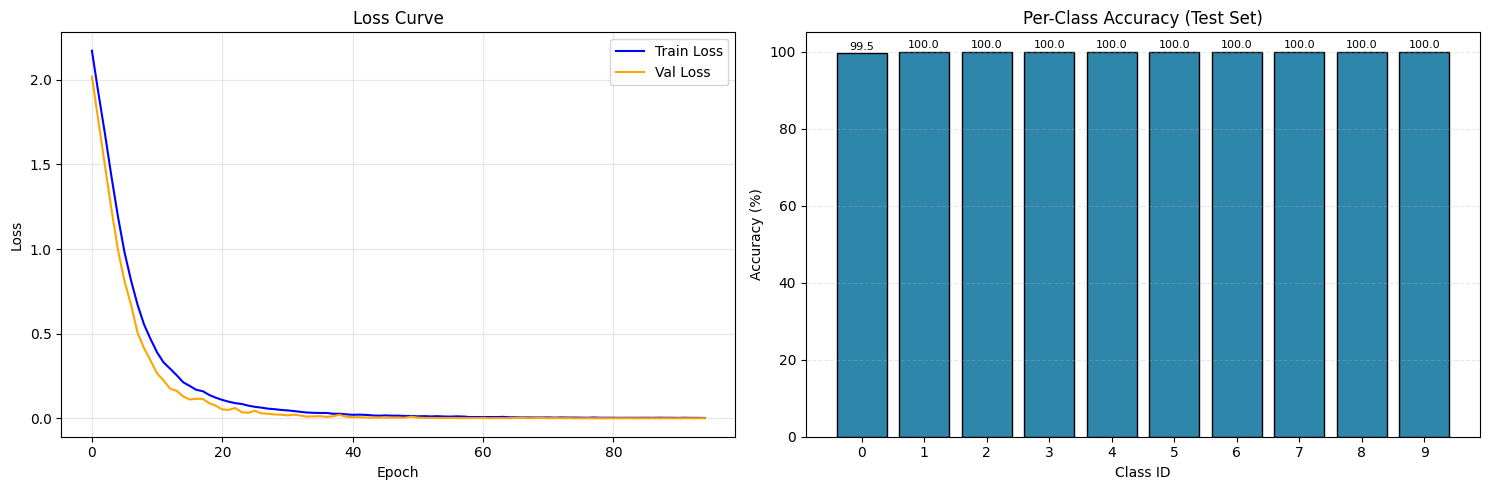

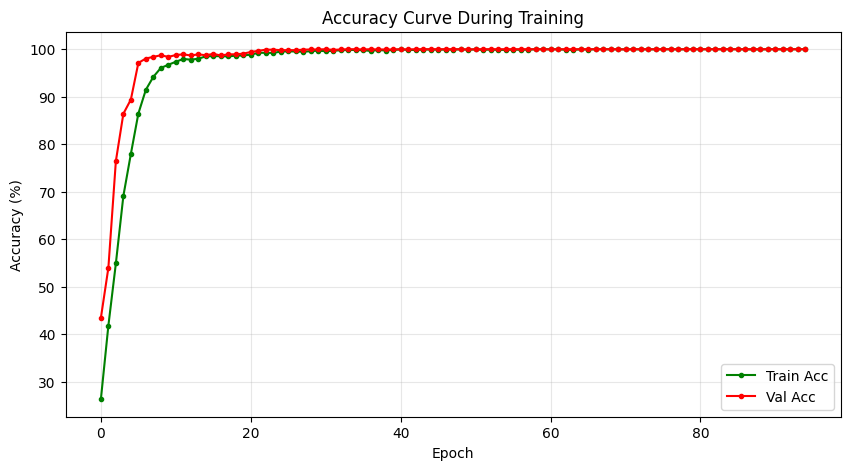

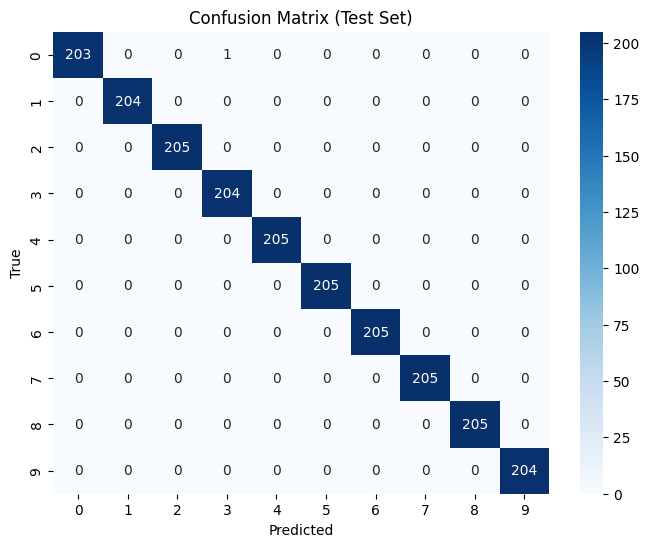

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # 用于绘制热力图
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tqdm import tqdm
import time
import os

# =================🎛️ 配置区域=================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 假设 label_map_8ch 已存在，如果没有请手动定义或注释掉相关行
try:
    NUM_CLASSES = len(label_map_8ch)
    class_names = list(label_map_8ch.keys()) # 获取类别名称
except NameError:
    print("⚠️ 未检测到 label_map_8ch，使用默认设置 (10类)")
    NUM_CLASSES = 10
    class_names = [f"Class_{i}" for i in range(NUM_CLASSES)]

INPUT_CHANNELS = 8
INPUT_LENGTH = 1027
LEARNING_RATE = 0.00001
EPOCHS = 500
PATIENCE = 10
BATCH_SIZE = 64

SAVE_DIR = 'data\mid_model'
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'best_fault_cnn_model.pth')
# =========================================

print(f"🤖 当前设备: {DEVICE}")
print(f"📦 类别数量: {NUM_CLASSES}")
print(f"🏷️  类别列表: {class_names}")

# ================= 1. 定义 1D-CNN 模型 =================
class FaultDiagnosisCNN(nn.Module):
    def __init__(self, num_classes, input_channels=8):
        super(FaultDiagnosisCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1))
        self.layer2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1))
        self.layer3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1))
        self.layer4 = nn.Sequential(
            nn.Conv1d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return self.classifier(x)

# 实例化模型
model = FaultDiagnosisCNN(num_classes=NUM_CLASSES, input_channels=INPUT_CHANNELS).to(DEVICE)

# ================= 2. 准备训练组件 =================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=False)

# ================= 3. 训练与验证函数 =================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc="Training", leave=False)
    for inputs, targets in pbar:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}"})
    return total_loss / total, 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return total_loss / total, 100. * correct / total

# ================= 4. 执行训练循环 (风格化 + 双准确率显示) =================
if 'train_loader' not in globals():
    raise RuntimeError("❌ 错误：未找到 train_loader。请先运行数据加载代码。")

print(f"\n🔥 开始训练 (Max Epochs={EPOCHS}, Patience={PATIENCE})...")

best_val_loss = float('inf')
best_val_acc = 0.0
best_epoch = 0
epochs_no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

# 记录总开始时间
total_start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    # 记录本轮开始时间
    epoch_start_time = time.time()

    # --- 训练 ---
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer,
                                            criterion, DEVICE)

    # --- 验证 ---
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)

    # 计算耗时
    epoch_duration = time.time() - epoch_start_time

    # 格式化当前轮次耗时 ( Xm Ys )
    m, s = divmod(epoch_duration, 60)
    time_str = f"{int(m)}m {int(s)}s"

    # 更新历史
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # 学习率调整
    scheduler.step(val_loss)

    # --- 打印风格化日志 (包含 Train/Val Acc) ---
    print("-" * 75)
    # 格式：Loss (高精度) | Acc (2位小数)
    print(f"Train_Loss: {train_loss:.16f} | Train_Acc: {train_acc:6.2f}%")
    print(f"Val_Loss:   {val_loss:.16f} | Val_Acc:   {val_acc:6.2f}%")
    print(
        f"Time: {time_str:<8} | epochs_since_improvement: {epochs_no_improve} | Epoch {epoch}/{EPOCHS}"
    )

    # --- 早停检查 & 保存最佳模型 (含星号提示) ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        best_epoch = epoch
        epochs_no_improve = 0

        # 保存最佳模型
        torch.save(
            {
                'epoch':
                epoch,
                'model_state_dict':
                model.state_dict(),
                'optimizer_state_dict':
                optimizer.state_dict(),
                'val_loss':
                val_loss,
                'val_acc':
                val_acc,
                'label_map':
                label_map_8ch if 'label_map_8ch' in globals() else None
            }, MODEL_SAVE_PATH)

        # 🌟 发现更佳模型提示
        print(
            f"   ⭐ 发现更佳模型！已保存至 '{MODEL_SAVE_PATH}' (Val Acc: {val_acc:.2f}%)")

    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("-" * 75)
            print(
                f"\nval loss did not improve for {PATIENCE} epochs. Training stops."
            )
            print(f"Early stopping at epoch {epoch}")
            break

# 计算总用时
total_duration = time.time() - total_start_time
m, s = divmod(total_duration, 60)
total_time_str = f"{int(m)}.m {s:.7f}s"

# ================= 5. 输出最终摘要 =================
print("-" * 75)
if epochs_no_improve >= PATIENCE:
    pass  # 早停信息已在循环内打印
else:
    print(f"\n✅ Training finished naturally (Reached Max Epochs).")

print(f"Best Epoch: {best_epoch}")
print(f"Best Val Loss: {best_val_loss:.16f}")
print(f"Best Val Acc : {best_val_acc:.2f}%")
print(f"Total Time: {total_time_str}")
print("=" * 75)

# ================= 6. 加载最佳模型并进行详细测试评估 =================
print("\n🔄 正在加载最佳模型权重进行测试集评估...")
if os.path.exists(MODEL_SAVE_PATH):
    checkpoint = torch.load(MODEL_SAVE_PATH,
                            map_location=DEVICE,
                            weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print("💾 最佳模型权重加载成功。")
else:
    print("⚠️ 警告：未找到模型文件。")


# 定义评估函数
def evaluate_per_class(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc="Testing", leave=True):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    return np.array(all_preds), np.array(all_targets)


if 'test_loader' in globals():
    preds, targets = evaluate_per_class(model, test_loader, DEVICE)

    overall_acc = accuracy_score(targets, preds) * 100
    cm = confusion_matrix(targets, preds)
    class_accs = cm.diagonal() / cm.sum(axis=1) * 100

    print(f"\n🧪 测试集最终结果 -> 整体准确率：{overall_acc:.2f}%")
    print(f"best_test_Acc: {overall_acc/100:.6f}")

    # 打印各类别准确率表格
    print("\n📊 各类别准确率详情:")
    print(
        f"{'ID':<5} | {'Name':<20} | {'Count':<8} | {'Correct':<8} | {'Acc (%)':<10}"
    )
    print("-" * 60)
    for i in range(NUM_CLASSES):
        name = class_names[i] if i < len(class_names) else f"Class_{i}"
        count = cm[i].sum()
        correct = cm[i][i]
        acc = class_accs[i]
        print(f"{i:<5} | {name:<20} | {count:<8} | {correct:<8} | {acc:.2f}")

    # --- 可视化 ---
    plt.figure(figsize=(15, 5))

    # 图 1: 训练曲线 (Loss & Acc 双Y轴或分开展示，这里展示Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'],
             label='Train Loss',
             color='blue',
             linestyle='-')
    plt.plot(history['val_loss'],
             label='Val Loss',
             color='orange',
             linestyle='-')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    # 图 2: 准确率曲线 (新增)
    # 为了清晰，我们单独画一个准确率图，或者替换掉原来的柱状图位置
    # 这里选择画准确率曲线，柱状图放到下一个figure或者省略，
    # 但为了保留之前的类别分析，我们画：左图(Loss), 右图(各类别Acc柱状图)
    # 如果想看训练过程的Acc曲线，可以取消下面注释并调整布局

    # 这里保持原计划：右图为测试集各类别准确率柱状图
    colors = [
        '#2E86AB' if x > 90 else '#F18F01' if x > 70 else '#C73E1D'
        for x in class_accs
    ]
    plt.subplot(1, 2, 2)
    plt.bar(range(NUM_CLASSES), class_accs, color=colors, edgecolor='black')
    plt.title('Per-Class Accuracy (Test Set)')
    plt.xlabel('Class ID')
    plt.ylabel('Accuracy (%)')
    plt.xticks(range(NUM_CLASSES))
    plt.ylim(0, 105)
    for i, v in enumerate(class_accs):
        plt.text(i, v + 1, f"{v:.1f}", ha='center', fontsize=8)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    # plt.savefig('training_summary.png', dpi=300)
    # print("\n📈 训练总结与类别分析图已保存为 'training_summary.png'")
    plt.show()

    # 额外绘制训练过程中的准确率曲线 (可选，单独显示)
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_acc'],
             label='Train Acc',
             color='green',
             marker='.')
    plt.plot(history['val_acc'], label='Val Acc', color='red', marker='.')
    plt.title('Accuracy Curve During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    # plt.savefig('accuracy_curve.png', dpi=300)
    # print("📈 训练准确率曲线图已保存为 'accuracy_curve.png'")
    plt.show()

    # 混淆矩阵
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=range(NUM_CLASSES),
                yticklabels=range(NUM_CLASSES))
    plt.title('Confusion Matrix (Test Set)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    # plt.savefig('confusion_matrix.png', dpi=300)
    plt.show()

else:
    print("⚠️ 未检测到 test_loader，跳过测试集评估。")

In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader, TensorDataset, random_split
# import numpy as np
# import matplotlib.pyplot as plt
# # 暂时不需要 tqdm 用于内部循环，避免卡死
# import os
# import copy
# import random
# import time

# # ================= 🎛️ 全局配置 =================
# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed(SEED)
#     torch.backends.cudnn.deterministic = True

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # 超参数 (已调小以便测试)
# INPUT_CHANNELS = 8
# INPUT_LENGTH = 2048
# LEARNING_RATE = 1e-5
# EPOCHS = 1000  # 建议先设小一点，通了再改大
# PATIENCE = 15
# BATCH_SIZE = 64

# try:
#     NUM_CLASSES = len(label_map_8ch)
#     print(f"✅ 检测到真实标签，类别数：{NUM_CLASSES}")
# except NameError:
#     NUM_CLASSES = 10
#     print("⚠️ 使用模拟数据，类别数：10")


# # ================= 🧪 1. 数据准备 =================
# def prepare_data():
#     if 'train_loader' in globals() and 'val_loader' in globals():
#         return train_loader, val_loader, test_loader

#     print("⏳ 生成模拟数据...")
#     total_samples = 2000  # 减少样本量加快测试
#     X = np.random.randn(total_samples, INPUT_CHANNELS,
#                         INPUT_LENGTH).astype(np.float32)
#     y = np.random.randint(0, NUM_CLASSES, size=(total_samples, ))

#     for i in range(total_samples):
#         t = np.linspace(0, 10, INPUT_LENGTH)
#         signal = np.sin(2 * np.pi * (y[i] + 1) * t) * np.exp(-t / 2)
#         X[i, y[i] % INPUT_CHANNELS, :] += signal * 2.0

#     dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
#     val_size = int(len(dataset) * 0.15)
#     test_size = int(len(dataset) * 0.15)
#     train_size = len(dataset) - val_size - test_size

#     train_ds, val_ds, test_ds = random_split(
#         dataset, [train_size, val_size, test_size],
#         generator=torch.Generator().manual_seed(SEED))

#     # num_workers=0 在 Jupyter 中最稳定，虽然慢点但不会卡死
#     return (DataLoader(train_ds,
#                        batch_size=BATCH_SIZE,
#                        shuffle=True,
#                        num_workers=0),
#             DataLoader(val_ds,
#                        batch_size=BATCH_SIZE,
#                        shuffle=False,
#                        num_workers=0),
#             DataLoader(test_ds,
#                        batch_size=BATCH_SIZE,
#                        shuffle=False,
#                        num_workers=0))


# train_loader, val_loader, test_loader = prepare_data()


# # ================= 🏗️ 2. 模型定义 =================
# class FaultDiagnosisCNN(nn.Module):

#     def __init__(self, num_classes, input_channels=8, depth=4):
#         super(FaultDiagnosisCNN, self).__init__()
#         if not (1 <= depth <= 4): raise ValueError("depth must be 1-4")

#         self.depth = depth
#         self.layers = nn.ModuleList()
#         configs = [(input_channels, 64, 7), (64, 128, 5), (128, 256, 5),
#                    (256, 512, 3)]

#         for i in range(depth):
#             in_ch, out_ch, k_size = configs[i]
#             stride = 2 if i == 0 else 1
#             self.layers.append(
#                 nn.Sequential(
#                     nn.Conv1d(in_ch,
#                               out_ch,
#                               kernel_size=k_size,
#                               stride=stride,
#                               padding=k_size // 2), nn.BatchNorm1d(out_ch),
#                     nn.ReLU(inplace=True),
#                     nn.MaxPool1d(kernel_size=3, stride=2, padding=1)))

#         final_channels = configs[depth - 1][1]
#         self.classifier = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
#                                         nn.Dropout(0.5),
#                                         nn.Linear(final_channels, 256),
#                                         nn.ReLU(inplace=True), nn.Dropout(0.3),
#                                         nn.Linear(256, num_classes))

#     def forward(self, x):
#         for layer in self.layers:
#             x = layer(x)
#         return self.classifier(x)


# # ================= ⚔️ 3. 训练工具 (移除 tqdm 内部刷新) =================
# def get_training_components(model):
#     criterion = nn.CrossEntropyLoss()
#     optimizer = optim.Adam(model.parameters(),
#                            lr=LEARNING_RATE,
#                            weight_decay=1e-4)
#     scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
#                                                      mode='min',
#                                                      factor=0.5,
#                                                      patience=5,
#                                                      verbose=False)
#     return criterion, optimizer, scheduler


# def train_one_epoch(model, loader, optimizer, criterion, device):
#     model.train()
#     total_loss, correct, total = 0.0, 0, 0

#     # 不再使用 tqdm 包装 loader，直接遍历，避免 IO 阻塞
#     for inputs, targets in loader:
#         inputs, targets = inputs.to(device), targets.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, targets)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item() * inputs.size(0)
#         _, predicted = outputs.max(1)
#         total += targets.size(0)
#         correct += predicted.eq(targets).sum().item()

#     return total_loss / total, 100. * correct / total


# def evaluate(model, loader, criterion, device):
#     model.eval()
#     total_loss, correct, total = 0.0, 0, 0
#     with torch.no_grad():
#         for inputs, targets in loader:
#             inputs, targets = inputs.to(device), targets.to(device)
#             outputs = model(inputs)
#             loss = criterion(outputs, targets)
#             total_loss += loss.item() * inputs.size(0)
#             _, predicted = outputs.max(1)
#             total += targets.size(0)
#             correct += predicted.eq(targets).sum().item()
#     return total_loss / total, 100. * correct / total


# # ================= 🚀 4. 主循环 =================
# depths_to_test = [1, 2, 3, 4]
# results_summary = []

# print(f"\n🔥 开始实验 (Device: {DEVICE})...")

# for d in depths_to_test:
#     print(f"\n🚀 [深度 {d}] 开始训练...")
#     start_time = time.time()

#     model = FaultDiagnosisCNN(num_classes=NUM_CLASSES,
#                               input_channels=INPUT_CHANNELS,
#                               depth=d).to(DEVICE)
#     total_params = sum(p.numel() for p in model.parameters())
#     criterion, optimizer, scheduler = get_training_components(model)

#     best_val_acc = 0.0
#     best_state_dict = None
#     epochs_no_improve = 0

#     # 动态调整 epoch
#     current_epochs = EPOCHS if d == 4 else min(EPOCHS, 150)

#     for epoch in range(1, current_epochs + 1):
#         train_loss, train_acc = train_one_epoch(model, train_loader, optimizer,
#                                                 criterion, DEVICE)
#         val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

#         scheduler.step(val_loss)

#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             best_state_dict = copy.deepcopy(model.state_dict())
#             epochs_no_improve = 0
#         else:
#             epochs_no_improve += 1

#         if epochs_no_improve >= PATIENCE:
#             print(f"   ⏹️ Early Stopping at Epoch {epoch}")
#             break

#         # 每 20 轮打印一次，而不是每批打印
#         if epoch % 20 == 0 or epoch == 1:
#             print(
#                 f"   Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.2f}%"
#             )

#     # 记录结果
#     if best_state_dict: model.load_state_dict(best_state_dict)
#     test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)

#     results_summary.append({
#         'depth': d,
#         'params': total_params,
#         'best_val_acc': best_val_acc,
#         'best_val_loss': 0,  # 简化记录
#         'final_test_acc': test_acc,
#         'final_test_loss': test_loss
#     })

#     duration = time.time() - start_time
#     print(
#         f"   ✅ 完成 (耗时 {duration:.1f}s) | Best Val Acc: {best_val_acc:.2f}% | Test Acc: {test_acc:.2f}%"
#     )

# # ================= 📊 5. 结果展示 =================
# print("\n" + "=" * 60)
# print(f"{'Depth':<6} | {'Params':<10} | {'Val Acc':<10} | {'Test Acc':<10}")
# print("-" * 60)
# for res in results_summary:
#     print(
#         f"{res['depth']:<6} | {res['params']:<10,} | {res['best_val_acc']:<10.2f} | {res['final_test_acc']:<10.2f}"
#     )

# # 绘图
# plt.figure(figsize=(10, 5))
# depths = [r['depth'] for r in results_summary]
# plt.plot(depths, [r['best_val_acc'] for r in results_summary],
#          'o-',
#          label='Val Acc')
# plt.plot(depths, [r['final_test_acc'] for r in results_summary],
#          's--',
#          label='Test Acc')
# plt.title('Model Depth Comparison')
# plt.xlabel('Depth')
# plt.ylabel('Accuracy (%)')
# plt.legend()
# plt.grid(True)
# plt.show()

# best_model = max(results_summary, key=lambda x: x['final_test_acc'])
# print(
#     f"\n🏆 最佳模型深度：{best_model['depth']} (Test Acc: {best_model['final_test_acc']:.2f}%)"
# )